In [1]:
# Cell 1: Import libraries and load the dataset
# WHY THIS CELL EXISTS: Before doing anything, we need pandas (for handling tabular data)
# and to load the raw CSV into memory as a DataFrame so we can start inspecting it.

import pandas as pd      # pandas = library for working with tables (like Excel, but code-driven)
import numpy as np       # numpy = library for numerical operations, used under the hood by pandas

# Because the notebook and the CSV are in the SAME folder, we only need the filename —
# no need to type the full C:\Users\Admin\... path.
df = pd.read_csv("ShopSphere_Conversion_Intelligence.csv")

# .shape tells us (number of rows, number of columns) — first sanity check on any dataset
print("Shape of dataset:", df.shape)

Shape of dataset: (50500, 39)


In [2]:
# Cell 2: Preview the data and check column types
# WHY THIS CELL EXISTS: We need to actually SEE what the data looks like — column names,
# sample values, and data types (numbers vs text vs dates) — before we can clean or analyze it.

df.head()          # .head() shows the first 5 rows of the table by default

,session_id,session_date,customer_id,customer_age,gender,city,customer_segment,days_since_registration,loyalty_member,session_duration_minutes,...,browser,device_age_days,discount_percentage,shipping_cost,cart_value,legacy_tracking_code,marketing_batch_id,crm_reference_number,session_color_code,conversion_flag
0,1000000,2025-04-26,221958,41,Male,Pune,New,1010,0,12.822282,...,Edge,1385,29.659102,122.636093,21035.190513,890837,2221,191892,Green,1
1,1000001,2025-01-09,771155,19,Male,Pune,VIP,1736,0,28.725897,...,Edge,193,8.636415,377.661767,42272.014659,160140,7076,727343,Blue,1
2,1000002,2025-09-28,231932,55,Female,Kolkata,Regular,982,1,28.015641,...,Edge,1747,25.450953,259.891509,39087.314569,251339,6936,448071,Red,1
3,1000003,2025-03-14,465838,39,Male,Delhi,VIP,399,1,48.933134,...,Chrome,1490,49.186502,233.515960,26183.578050,866793,3323,407229,Black,1
4,1000004,2026-05-22,359178,46,Female,Pune,Regular,291,0,25.710950,...,Safari,83,15.366621,256.450101,15029.374725,984293,4042,278066,Red,1


In [3]:
# Cell 3: Widen the display and inspect data types
# WHY THIS CELL EXISTS: By default, pandas hides middle columns when there are too many
# to fit on screen (that's the "..." you just saw). We remove that limit so nothing is
# hidden from us during analysis. We also check .dtypes so we know which columns are
# numbers, which are text, and which are dates — this affects how we clean and analyze each one.

pd.set_option('display.max_columns', None)   # None = no limit; show ALL columns, never truncate

df.dtypes    # .dtypes shows the data type pandas assigned to each column

session_id                    int64
session_date                 object
customer_id                   int64
customer_age                  int64
gender                       object
city                         object
customer_segment             object
days_since_registration       int64
loyalty_member                int64
session_duration_minutes    float64
pages_visited                 int64
products_viewed               int64
search_count                  int64
categories_viewed             int64
wishlist_additions            int64
cart_additions                int64
product_reviews_read          int64
discount_viewed               int64
campaign_id                   int64
campaign_type                object
traffic_source               object
ad_clicks                     int64
email_clicks                  int64
previous_purchases            int64
average_order_value         float64
days_since_last_purchase      int64
customer_rating             float64
device_type                 

In [4]:
# Cell 4: Check for missing values and duplicate rows
# WHY THIS CELL EXISTS: Before any analysis, we must know if data is missing (blank cells)
# or duplicated (the same row appearing more than once), because both distort results if
# left untreated. This is a required step in any data science project (Data Understanding
# stage), and we must document what we find as an "assumption/limitation" in our report.

print("Missing values per column:")
print(df.isnull().sum())          # counts blanks/NaNs in each column

print("\nNumber of fully duplicate rows:", df.duplicated().sum())   # counts exact repeat rows

Missing values per column:
session_id                     0
session_date                   0
customer_id                    0
customer_age                   0
gender                         0
city                           0
customer_segment               0
days_since_registration        0
loyalty_member                 0
session_duration_minutes       0
pages_visited                  0
products_viewed                0
search_count                   0
categories_viewed              0
wishlist_additions             0
cart_additions                 0
product_reviews_read           0
discount_viewed                0
campaign_id                    0
campaign_type                  0
traffic_source                 0
ad_clicks                      0
email_clicks                   0
previous_purchases             0
average_order_value         4911
days_since_last_purchase       0
customer_rating             5050
device_type                    0
operating_system               0
browser         

In [5]:
# Cell 5: Check unique values in each text (categorical) column
# WHY THIS CELL EXISTS: Text data often has inconsistent formatting (e.g. "Mobile" vs
# "mobile" vs "MOBILE") that LOOKS like the same category to a human but is treated as
# THREE different categories by the computer. We must find and fix this before analysis,
# or it will silently corrupt any grouping, counting, or modeling we do later.

# First, we get a list of only the text-type ("object") columns automatically
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print("Text columns found:", categorical_cols)

print("\n--- Unique values in each text column ---")
for col in categorical_cols:
    print(f"\n{col}: {df[col].unique()}")

Text columns found: ['session_date', 'gender', 'city', 'customer_segment', 'campaign_type', 'traffic_source', 'device_type', 'operating_system', 'browser', 'session_color_code']

--- Unique values in each text column ---

session_date: ['2025-04-26' '2025-01-09' '2025-09-28' '2025-03-14' '2026-05-22'
 '2025-05-14' '2025-07-26' '2024-11-08' '2025-09-16' '2024-11-29'
 '2026-05-02' '2025-11-03' '2025-12-19' '2025-10-28' '2024-12-30'
 '2025-01-10' '2025-02-06' '2026-05-24' '2024-06-24' '2026-02-20'
 '2025-08-14' '2024-07-18' '2025-05-06' '2025-06-12' '2024-09-11'
 '2026-01-21' '2024-11-10' '2026-04-30' '2024-11-05' '2024-09-03'
 '2024-07-09' '2025-08-22' '2024-08-19' '2025-08-11' '2024-09-13'
 '2025-07-22' '2025-09-09' '2025-02-08' '2024-08-31' '2025-10-24'
 '2025-02-21' '2025-12-26' '2026-01-22' '2025-08-04' '2025-08-08'
 '2025-11-29' '2025-09-20' '2025-11-11' '2024-08-20' '2024-09-12'
 '2024-07-30' '2026-03-04' '2025-12-30' '2024-11-04' '2025-12-25'
 '2026-06-03' '2024-08-16' '2025-05-10

In [6]:
# Cell 6: Standardize device_type values
# WHY THIS CELL EXISTS: We found that "Mobile", "MOBILE", and "mobile" are being treated
# as 3 separate categories by the computer, even though they mean the same thing to a
# human. If we don't fix this, any count, chart, or model using device_type will be wrong
# — e.g. "Mobile" might look less common than it really is because its count is split
# three ways.

# .str.lower() converts every value in the column to lowercase.
# .str.capitalize() then makes only the first letter uppercase (e.g. "mobile" -> "Mobile").
# Together, this forces "Mobile", "MOBILE", "mobile" to all become "Mobile".
df['device_type'] = df['device_type'].str.lower().str.capitalize()

# Confirm the fix worked — should now show only 3 categories: Mobile, Laptop, Tablet
print(df['device_type'].unique())

['Mobile' 'Laptop' 'Tablet']


In [7]:
# Cell 7: Remove duplicate rows
# WHY THIS CELL EXISTS: Earlier we found 500 rows that are byte-for-byte identical to
# other rows in the dataset. Duplicate rows are almost always a data collection/export
# error (e.g. the same session logged twice), not real repeated events. If left in, they
# artificially inflate certain patterns and bias any model we train later. We remove them
# and confirm the new row count.

print("Rows before removing duplicates:", df.shape[0])

df = df.drop_duplicates()   # keeps the first occurrence of each row, removes the rest

print("Rows after removing duplicates:", df.shape[0])

Rows before removing duplicates: 50500
Rows after removing duplicates: 50000


In [8]:
# Cell 8: Check distribution of columns with missing values
# WHY THIS CELL EXISTS: Before filling in missing values, we must decide HOW to fill them.
# The right choice (mean vs median vs something else) depends on whether the column's
# values are roughly symmetric or skewed (lopsided) by outliers. .describe() gives us
# the summary statistics needed to make that call responsibly, instead of guessing.

print("average_order_value summary:")
print(df['average_order_value'].describe())

print("\ncustomer_rating summary:")
print(df['customer_rating'].describe())

average_order_value summary:
count    45137.000000
mean      2501.174338
std        994.525598
min        100.000000
25%       1824.169645
50%       2497.131552
75%       3173.890755
max       6342.709284
Name: average_order_value, dtype: float64

customer_rating summary:
count    44989.000000
mean         3.000113
std          1.154147
min          1.000011
25%          1.996419
50%          2.998556
75%          4.000585
max          4.999992
Name: customer_rating, dtype: float64


In [9]:
# Cell 9: Fill missing values using the median
# WHY THIS CELL EXISTS: Both columns showed roughly symmetric distributions (mean ≈
# median), so filling missing entries with the median is a safe, standard choice — it
# won't distort the overall pattern of the data. We fill rather than drop these rows
# because dropping ~10% of rows would lose a meaningful amount of data unnecessarily.

# .median() calculates the middle value of the column, ignoring missing values automatically
aov_median = df['average_order_value'].median()
rating_median = df['customer_rating'].median()

print("Median average_order_value:", aov_median)
print("Median customer_rating:", rating_median)

# .fillna(value) replaces every missing (NaN) entry in the column with the given value
df['average_order_value'] = df['average_order_value'].fillna(aov_median)
df['customer_rating'] = df['customer_rating'].fillna(rating_median)

# Confirm no missing values remain in these two columns
print("\nRemaining missing values:")
print(df[['average_order_value', 'customer_rating']].isnull().sum())

Median average_order_value: 2497.131551933201
Median customer_rating: 2.998555886367179

Remaining missing values:
average_order_value    0
customer_rating        0
dtype: int64


In [10]:
# Cell 10: Convert session_date from text to an actual date type
# WHY THIS CELL EXISTS: Right now session_date is stored as plain text (e.g. "2025-04-26"),
# which means pandas can't do date-based operations on it — like extracting the month,
# sorting chronologically, or calculating time differences. Converting it to a proper
# datetime type unlocks all of that for later analysis (e.g. "does conversion rate vary
# by month or day of week?").

df['session_date'] = pd.to_datetime(df['session_date'])

# Confirm the conversion worked - dtype should now show datetime64 instead of object
print(df['session_date'].dtype)

# Also check the actual date range, to sanity-check the data covers a sensible period
print("Earliest session date:", df['session_date'].min())
print("Latest session date:", df['session_date'].max())

datetime64[ns]
Earliest session date: 2024-06-08 00:00:00
Latest session date: 2026-06-08 00:00:00


In [11]:
# Cell 11: Test whether legacy/ID columns have any real relationship with conversion
# WHY THIS CELL EXISTS: The business problem statement mentions "legacy attributes
# inherited from previous marketing platforms" — these are often meaningless leftover
# ID numbers with no real business signal. Rather than assuming that and dropping them
# blindly, we PROVE it by checking their correlation with the target variable. A
# correlation near 0 means "no linear relationship" — strong evidence the column is noise.

junk_candidates = ['legacy_tracking_code', 'marketing_batch_id', 'crm_reference_number', 'campaign_id']

for col in junk_candidates:
    correlation = df[col].corr(df['conversion_flag'])
    print(f"{col}: correlation with conversion_flag = {correlation:.4f}")

# session_color_code is text, not a number, so we check it differently:
# we look at the conversion RATE within each color category. If every color has
# roughly the same conversion rate, the color has no relationship with conversion.
print("\nConversion rate by session_color_code:")
print(df.groupby('session_color_code')['conversion_flag'].mean())

legacy_tracking_code: correlation with conversion_flag = -0.0065
marketing_batch_id: correlation with conversion_flag = -0.0017
crm_reference_number: correlation with conversion_flag = 0.0081
campaign_id: correlation with conversion_flag = 0.0048

Conversion rate by session_color_code:
session_color_code
Black    0.841934
Blue     0.836035
Green    0.836833
Red      0.835883
Name: conversion_flag, dtype: float64


In [12]:
# Cell 12: Drop columns confirmed to have no relationship with the target
# WHY THIS CELL EXISTS: Cell 11 proved (not assumed) that these 5 columns carry no
# meaningful signal for predicting conversion. session_id is also dropped: it's a unique
# row identifier with no repeat meaning. customer_id is DELIBERATELY KEPT for now, even
# though it will NOT be used as a model feature -- we're preserving it to analyze
# repeat-customer behavior later (1,800 customers appear more than once in this data).

cols_to_drop = ['legacy_tracking_code', 'marketing_batch_id', 'crm_reference_number',
                'campaign_id', 'session_color_code', 'session_id']

print("Columns before dropping:", df.shape[1])

df = df.drop(columns=cols_to_drop)

print("Columns after dropping:", df.shape[1])
print("\nRemaining columns:", df.columns.tolist())

Columns before dropping: 39
Columns after dropping: 33

Remaining columns: ['session_date', 'customer_id', 'customer_age', 'gender', 'city', 'customer_segment', 'days_since_registration', 'loyalty_member', 'session_duration_minutes', 'pages_visited', 'products_viewed', 'search_count', 'categories_viewed', 'wishlist_additions', 'cart_additions', 'product_reviews_read', 'discount_viewed', 'campaign_type', 'traffic_source', 'ad_clicks', 'email_clicks', 'previous_purchases', 'average_order_value', 'days_since_last_purchase', 'customer_rating', 'device_type', 'operating_system', 'browser', 'device_age_days', 'discount_percentage', 'shipping_cost', 'cart_value', 'conversion_flag']


In [13]:
# Cell 13: Save the cleaned dataset to a new file
# WHY THIS CELL EXISTS: We don't want to overwrite the original raw CSV (always keep raw
# data untouched, as a matter of good practice and reproducibility). Instead we save our
# cleaned version under a new name. This becomes a checkpoint: if the notebook crashes or
# you close Jupyter, you can reload this cleaned file directly instead of re-running every
# cleaning step from scratch.

df.to_csv("ShopSphere_Cleaned.csv", index=False)

print("Cleaned dataset saved as ShopSphere_Cleaned.csv")
print("Final shape:", df.shape)

Cleaned dataset saved as ShopSphere_Cleaned.csv
Final shape: (50000, 33)


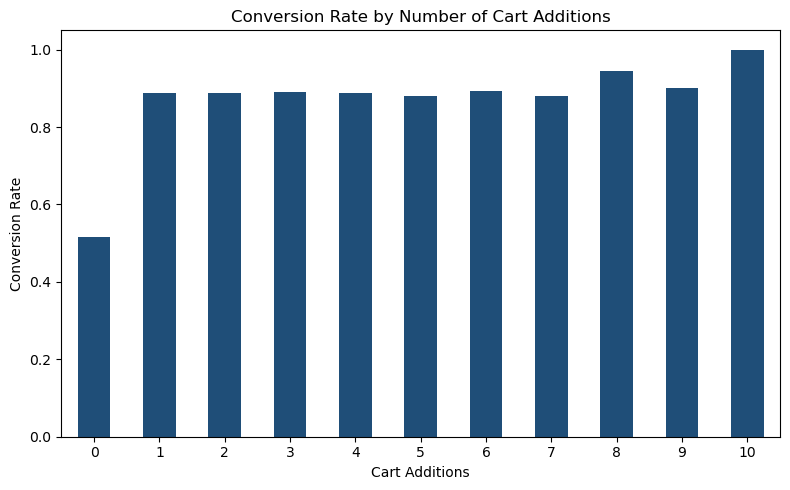

In [14]:
# Cell 14: Visualize conversion rate across cart_additions values
# WHY THIS CELL EXISTS: We saw a suspicious pattern earlier (conversion jumps from ~52% to
# ~88-90% the moment cart_additions goes from 0 to 1). A table of numbers can hide or
# exaggerate patterns; a chart makes the shape of the relationship immediately obvious,
# and is also something we can put directly in the EDA section of the final report.

import matplotlib.pyplot as plt

# Group by cart_additions, calculate mean conversion rate for each group
conversion_by_cart = df.groupby('cart_additions')['conversion_flag'].mean()

plt.figure(figsize=(8, 5))
conversion_by_cart.plot(kind='bar', color='#1F4E78')
plt.title('Conversion Rate by Number of Cart Additions')
plt.xlabel('Cart Additions')
plt.ylabel('Conversion Rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('cart_additions_conversion.png', dpi=150)
plt.show()

In [15]:
# Cell 15: Quantify how much of the population falls on each side of the cart_additions cliff
# WHY THIS CELL EXISTS: The chart shows a cliff between 0 and 1+ cart additions, but we don't
# yet know how many sessions fall into each group. If almost everyone has cart_additions >= 1,
# this variable barely matters in practice even if it's suspicious in theory. If it's a large
# and meaningful split, it matters a lot for both leakage risk and modeling.

df['has_cart_addition'] = (df['cart_additions'] > 0).astype(int)

print(df['has_cart_addition'].value_counts())
print()
print(df['has_cart_addition'].value_counts(normalize=True))
print()
print("Conversion rate when has_cart_addition = 0:", df[df['has_cart_addition']==0]['conversion_flag'].mean())
print("Conversion rate when has_cart_addition = 1:", df[df['has_cart_addition']==1]['conversion_flag'].mean())

has_cart_addition
1    43192
0     6808
Name: count, dtype: int64

has_cart_addition
1    0.86384
0    0.13616
Name: proportion, dtype: float64

Conversion rate when has_cart_addition = 0: 0.5168918918918919
Conversion rate when has_cart_addition = 1: 0.888243193183923


In [16]:
# Cell 16: Check how well cart_additions ALONE predicts conversion
# WHY THIS CELL EXISTS: If a single yes/no feature can already achieve high accuracy on its
# own, that's a strong practical warning sign of leakage -- a model built on this feature
# might look impressive while actually just learning a shortcut ("if cart_additions > 0,
# predict converted") rather than genuinely modeling customer behavior. We compare this
# simple rule against two baselines: (a) always guessing the majority class, and (b) the
# actual accuracy this one rule would achieve.

# Baseline 1: if we always predicted the majority class (converted, since 83.8% convert)
majority_baseline = df['conversion_flag'].mean()
print(f"Baseline (always predict 'converted'): {majority_baseline:.4f} accuracy")

# Rule: predict converted (1) whenever has_cart_addition == 1, else predict not converted (0)
df['naive_prediction'] = df['has_cart_addition']

# Accuracy = fraction of rows where our naive prediction matches the real outcome
naive_accuracy = (df['naive_prediction'] == df['conversion_flag']).mean()
print(f"Naive rule (cart_additions > 0 -> converted): {naive_accuracy:.4f} accuracy")

Baseline (always predict 'converted'): 0.8377 accuracy
Naive rule (cart_additions > 0 -> converted): 0.8331 accuracy


In [17]:
# Cell 17: Check recall on each class specifically, not just overall accuracy
# WHY THIS CELL EXISTS: Cell 16 showed accuracy is misleading here due to class imbalance.
# What actually matters for the business (identifying low-propensity sessions worth
# re-targeting) is: of all the sessions that did NOT convert, how many does this rule
# correctly catch? That's "recall on the non-converted class" -- a completely different
# question from overall accuracy.

from sklearn.metrics import classification_report

print(classification_report(df['conversion_flag'], df['naive_prediction'],
                             target_names=['Not Converted', 'Converted']))

               precision    recall  f1-score   support

Not Converted       0.48      0.41      0.44      8116
    Converted       0.89      0.92      0.90     41884

     accuracy                           0.83     50000
    macro avg       0.69      0.66      0.67     50000
 weighted avg       0.82      0.83      0.83     50000



In [18]:
# Cell 18: Check whether the cart_additions effect holds the same way across every channel
# WHY THIS CELL EXISTS: If cart_additions predicts conversion identically in every traffic
# source (Email, Paid Search, Organic, etc.), that consistency is itself informative -- a
# real behavioral signal usually varies by context (e.g. paid traffic might behave
# differently from organic), whereas a suspiciously uniform effect across all channels is
# more consistent with an artifact of how the data was constructed.

pivot = df.groupby(['traffic_source', 'has_cart_addition'])['conversion_flag'].mean().unstack()
pivot.columns = ['No Cart Addition', 'Has Cart Addition']
print(pivot)

                No Cart Addition  Has Cart Addition
traffic_source                                     
Email                   0.509491           0.891246
Organic                 0.505132           0.884428
Paid Search             0.515419           0.890438
Referral                0.514953           0.886213
Social                  0.538737           0.888850


In [19]:
# Cell 19: Remove the scratch test column, keep the real engineered feature
# WHY THIS CELL EXISTS: naive_prediction was only created to test a hypothesis (Cell 16) --
# it's literally a duplicate of has_cart_addition and has no purpose going forward. Leaving
# scratch columns like this in df risks them accidentally being fed into a real model later
# (a genuine leakage risk in itself, ironically). has_cart_addition is kept -- it's a real,
# documented engineered feature we may use later, separate from raw cart_additions.

df = df.drop(columns=['naive_prediction'])

print("Columns remaining:", df.shape[1])
print(df.columns.tolist())

Columns remaining: 34
['session_date', 'customer_id', 'customer_age', 'gender', 'city', 'customer_segment', 'days_since_registration', 'loyalty_member', 'session_duration_minutes', 'pages_visited', 'products_viewed', 'search_count', 'categories_viewed', 'wishlist_additions', 'cart_additions', 'product_reviews_read', 'discount_viewed', 'campaign_type', 'traffic_source', 'ad_clicks', 'email_clicks', 'previous_purchases', 'average_order_value', 'days_since_last_purchase', 'customer_rating', 'device_type', 'operating_system', 'browser', 'device_age_days', 'discount_percentage', 'shipping_cost', 'cart_value', 'conversion_flag', 'has_cart_addition']


In [20]:
# Cell 20: Rank all numeric features by their correlation with conversion
# WHY THIS CELL EXISTS: Rather than testing each behavioral variable one at a time by
# guesswork, we systematically rank ALL numeric columns by how strongly they correlate
# with conversion_flag. This tells us where to focus next -- any variable with an
# unusually high correlation deserves the same scrutiny we just gave cart_additions.

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols.remove('conversion_flag')  # don't correlate the target with itself
numeric_cols.remove('customer_id')      # not a real feature, just an identifier

correlations = df[numeric_cols].corrwith(df['conversion_flag']).sort_values(ascending=False)
print(correlations)

has_cart_addition           0.345383
cart_additions              0.194823
wishlist_additions          0.184600
discount_viewed             0.128597
previous_purchases          0.116671
pages_visited               0.096373
session_duration_minutes    0.050885
days_since_last_purchase    0.008943
device_age_days             0.004073
categories_viewed           0.002728
customer_rating             0.002048
discount_percentage         0.001618
products_viewed             0.001556
cart_value                  0.000633
days_since_registration     0.000300
search_count                0.000012
email_clicks               -0.000680
average_order_value        -0.000873
product_reviews_read       -0.001528
shipping_cost              -0.001808
customer_age               -0.002664
ad_clicks                  -0.002667
loyalty_member             -0.003625
dtype: float64


In [21]:
# Cell 21: Check if wishlist_additions and discount_viewed show a similar step-function
# pattern to cart_additions, or a smoother, more gradual relationship
# WHY THIS CELL EXISTS: These are the next two behavioral variables by correlation strength.
# Before trusting them as clean features, we check whether they show the same suspicious
# "one big jump then flat" shape we found in cart_additions, or a genuinely gradual pattern.

print("Conversion rate by wishlist_additions:")
print(df.groupby('wishlist_additions')['conversion_flag'].mean())

print("\nConversion rate by discount_viewed:")
print(df.groupby('discount_viewed')['conversion_flag'].mean())

Conversion rate by wishlist_additions:
wishlist_additions
0    0.719894
1    0.907771
2    0.905298
3    0.908146
4    0.888451
5    0.927152
6    0.846154
7    1.000000
Name: conversion_flag, dtype: float64

Conversion rate by discount_viewed:
discount_viewed
0    0.779632
1    0.876417
Name: conversion_flag, dtype: float64


In [22]:
# Cell 22: Check population split for wishlist_additions, same diagnostic as cart_additions
# WHY THIS CELL EXISTS: The jump size alone doesn't tell us how many sessions are affected.
# We need this to judge how much this pattern matters in practice, same reasoning as Cell 15.

df['has_wishlist_addition'] = (df['wishlist_additions'] > 0).astype(int)
print(df['has_wishlist_addition'].value_counts(normalize=True))

has_wishlist_addition
1    0.63064
0    0.36936
Name: proportion, dtype: float64


In [23]:
# Cell 23: Confirm final column state after this diagnostic thread
# WHY THIS CELL EXISTS: We've added two engineered binary features during this investigation
# (has_cart_addition, has_wishlist_addition) and removed one scratch column (naive_prediction).
# This checkpoint confirms df is in the exact state we intend before moving to the next
# EDA thread, so nothing accidental carries forward.

print("Total columns:", df.shape[1])
print(df.columns.tolist())

Total columns: 35
['session_date', 'customer_id', 'customer_age', 'gender', 'city', 'customer_segment', 'days_since_registration', 'loyalty_member', 'session_duration_minutes', 'pages_visited', 'products_viewed', 'search_count', 'categories_viewed', 'wishlist_additions', 'cart_additions', 'product_reviews_read', 'discount_viewed', 'campaign_type', 'traffic_source', 'ad_clicks', 'email_clicks', 'previous_purchases', 'average_order_value', 'days_since_last_purchase', 'customer_rating', 'device_type', 'operating_system', 'browser', 'device_age_days', 'discount_percentage', 'shipping_cost', 'cart_value', 'conversion_flag', 'has_cart_addition', 'has_wishlist_addition']


In [24]:
# Cell 24: Check conversion rate across campaign types and traffic sources
# WHY THIS CELL EXISTS: The business problem statement centers on Marketing's complaint --
# high clicks, few conversions. We already found ad_clicks/email_clicks barely correlate
# with conversion (Cell 20). This checks whether the CATEGORY of campaign/channel matters
# instead, which is the more actionable question for targeting decisions.

print("Conversion rate by campaign_type:")
print(df.groupby('campaign_type')['conversion_flag'].mean().sort_values(ascending=False))

print("\nConversion rate by traffic_source:")
print(df.groupby('traffic_source')['conversion_flag'].mean().sort_values(ascending=False))

print("\nSession count by campaign_type (so we know if any category is too small to trust):")
print(df['campaign_type'].value_counts())

print("\nSession count by traffic_source:")
print(df['traffic_source'].value_counts())

Conversion rate by campaign_type:
campaign_type
Affiliate       0.842566
Social Media    0.838434
Search          0.837433
Email           0.836661
Display         0.833163
Name: conversion_flag, dtype: float64

Conversion rate by traffic_source:
traffic_source
Email          0.840676
Social         0.840020
Paid Search    0.839941
Referral       0.835139
Organic        0.832599
Name: conversion_flag, dtype: float64

Session count by campaign_type (so we know if any category is too small to trust):
campaign_type
Social Media    10194
Affiliate       10055
Email           10016
Search           9959
Display          9776
Name: count, dtype: int64

Session count by traffic_source:
traffic_source
Paid Search    10115
Social          9995
Organic         9982
Referral        9966
Email           9942
Name: count, dtype: int64


In [25]:
# Cell 25: Check conversion rate across customer_segment, gender, city, and device_type
# WHY THIS CELL EXISTS: We saw a hint during initial profiling that customer_segment might
# be flat (uninformative) like campaign_type turned out to be. Checking it properly now,
# alongside a few other categorical variables we haven't tested yet, so we build a complete
# picture of which categorical variables matter before moving to time-based analysis.

for col in ['customer_segment', 'gender', 'city', 'device_type']:
    print(f"Conversion rate by {col}:")
    print(df.groupby(col)['conversion_flag'].mean().sort_values(ascending=False))
    print()

Conversion rate by customer_segment:
customer_segment
VIP        0.839781
Premium    0.839468
New        0.835921
Regular    0.835582
Name: conversion_flag, dtype: float64

Conversion rate by gender:
gender
Female    0.838468
Male      0.836889
Name: conversion_flag, dtype: float64

Conversion rate by city:
city
Bangalore    0.840291
Kolkata      0.839271
Delhi        0.838342
Chennai      0.837357
Mumbai       0.837268
Pune         0.836940
Hyderabad    0.834318
Name: conversion_flag, dtype: float64

Conversion rate by device_type:
device_type
Tablet    0.840560
Mobile    0.837535
Laptop    0.835008
Name: conversion_flag, dtype: float64



In [26]:
# Cell 26: Extract month and day-of-week from session_date, check conversion patterns
# WHY THIS CELL EXISTS: session_date was converted to a proper datetime type back in Cell 10,
# but we haven't used it for anything yet. Real e-commerce often shows seasonal or weekday
# effects (e.g. weekend browsing vs weekday buying). We extract usable time components and
# check if conversion varies by them, following the same flat-vs-signal test as everything else.

df['session_month'] = df['session_date'].dt.month
df['session_dayofweek'] = df['session_date'].dt.day_name()

print("Conversion rate by month:")
print(df.groupby('session_month')['conversion_flag'].mean())

print("\nConversion rate by day of week:")
print(df.groupby('session_dayofweek')['conversion_flag'].mean().sort_values(ascending=False))

Conversion rate by month:
session_month
1     0.837676
2     0.830473
3     0.841558
4     0.840948
5     0.835685
6     0.828571
7     0.843795
8     0.844935
9     0.839220
10    0.839264
11    0.833496
12    0.836146
Name: conversion_flag, dtype: float64

Conversion rate by day of week:
session_dayofweek
Sunday       0.846483
Monday       0.839011
Friday       0.838213
Wednesday    0.836177
Saturday     0.835296
Tuesday      0.834351
Thursday     0.834068
Name: conversion_flag, dtype: float64


In [27]:
# Cell 27: Check multicollinearity among the behavioral features that showed real signal
# WHY THIS CELL EXISTS: Several behavioral variables (cart_additions, wishlist_additions,
# pages_visited, products_viewed, etc.) likely move together -- customers who browse more
# tend to view more products AND add more to cart AND wishlist. If two features are highly
# correlated with EACH OTHER (not just with the target), keeping both adds redundancy
# without adding real information, and can make model interpretation (e.g. SHAP) messier.

behavioral_cols = ['session_duration_minutes', 'pages_visited', 'products_viewed',
                    'search_count', 'categories_viewed', 'wishlist_additions',
                    'cart_additions', 'product_reviews_read', 'discount_viewed',
                    'previous_purchases']

correlation_matrix = df[behavioral_cols].corr()
print(correlation_matrix.round(2))

                          session_duration_minutes  pages_visited  \
session_duration_minutes                      1.00          -0.00   
pages_visited                                -0.00           1.00   
products_viewed                              -0.00           0.00   
search_count                                  0.01           0.01   
categories_viewed                             0.01           0.00   
wishlist_additions                            0.01           0.00   
cart_additions                               -0.00           0.01   
product_reviews_read                         -0.00          -0.00   
discount_viewed                              -0.00           0.00   
previous_purchases                            0.00          -0.00   

                          products_viewed  search_count  categories_viewed  \
session_duration_minutes            -0.00          0.01               0.01   
pages_visited                        0.00          0.01               0.00   
produc

In [28]:
# Cell 28: Define the two feature sets for the dual-pipeline leakage test (H1)
# WHY THIS CELL EXISTS: Our pre-submission document committed to testing whether
# cart_additions constitutes leakage by comparing a model WITH it (Model A) against a
# model WITHOUT it and other late-funnel signals (Model B). This cell defines exactly
# which columns go into each, so both models are built on a clear, documented, reproducible
# feature set rather than an ad-hoc one decided later.

# Columns that are never real features (identifiers, raw date, target itself)
exclude_always = ['customer_id', 'session_date', 'session_dayofweek', 'conversion_flag']

# Late-funnel / suspected leakage-risk columns (from our EDA investigation)
late_funnel_cols = ['cart_additions', 'has_cart_addition', 'cart_value',
                     'wishlist_additions', 'has_wishlist_addition']

all_cols = df.columns.tolist()

# Model A: everything except identifiers/target (includes late-funnel signals)
model_a_features = [c for c in all_cols if c not in exclude_always]

# Model B: Model A's features MINUS the late-funnel signals
model_b_features = [c for c in model_a_features if c not in late_funnel_cols]

print(f"Model A (full feature set): {len(model_a_features)} features")
print(model_a_features)
print(f"\nModel B (pre-cart / early-funnel only): {len(model_b_features)} features")
print(model_b_features)

Model A (full feature set): 33 features
['customer_age', 'gender', 'city', 'customer_segment', 'days_since_registration', 'loyalty_member', 'session_duration_minutes', 'pages_visited', 'products_viewed', 'search_count', 'categories_viewed', 'wishlist_additions', 'cart_additions', 'product_reviews_read', 'discount_viewed', 'campaign_type', 'traffic_source', 'ad_clicks', 'email_clicks', 'previous_purchases', 'average_order_value', 'days_since_last_purchase', 'customer_rating', 'device_type', 'operating_system', 'browser', 'device_age_days', 'discount_percentage', 'shipping_cost', 'cart_value', 'has_cart_addition', 'has_wishlist_addition', 'session_month']

Model B (pre-cart / early-funnel only): 28 features
['customer_age', 'gender', 'city', 'customer_segment', 'days_since_registration', 'loyalty_member', 'session_duration_minutes', 'pages_visited', 'products_viewed', 'search_count', 'categories_viewed', 'product_reviews_read', 'discount_viewed', 'campaign_type', 'traffic_source', 'ad_cl

In [29]:
# Cell 29: Convert categorical (text) columns into numeric columns models can use
# WHY THIS CELL EXISTS: Machine learning models work with numbers, not text categories.
# "One-hot encoding" converts each category into its own 0/1 column (e.g., city_Mumbai,
# city_Pune, etc.) rather than assigning arbitrary numbers like 1,2,3 to categories --
# arbitrary numbers would wrongly imply an order (e.g. that Pune > Mumbai), which makes
# no sense for a column with no natural ranking.

categorical_cols = ['gender', 'city', 'customer_segment', 'campaign_type',
                     'traffic_source', 'device_type', 'operating_system', 'browser']

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Shape before encoding:", df.shape)
print("Shape after encoding:", df_encoded.shape)

Shape before encoding: (50000, 37)
Shape after encoding: (50000, 55)


In [30]:
# Cell 30: Translate model_a_features / model_b_features into their encoded column names
# WHY THIS CELL EXISTS: Our feature lists (Cell 28) still reference original column names
# like 'gender', but after one-hot encoding, 'gender' no longer exists as a single column --
# it's now 'gender_Male' (and similar for every other categorical column). This cell expands
# each feature list so it correctly picks up all the new dummy columns for any categorical
# variable that was included, while leaving numeric variables untouched.

def expand_feature_list(feature_list, encoded_columns, categorical_cols):
    expanded = []
    for f in feature_list:
        if f in categorical_cols:
            # find every encoded column that starts with "columnname_"
            matches = [c for c in encoded_columns if c.startswith(f + '_')]
            expanded.extend(matches)
        else:
            expanded.append(f)
    return expanded

model_a_encoded = expand_feature_list(model_a_features, df_encoded.columns, categorical_cols)
model_b_encoded = expand_feature_list(model_b_features, df_encoded.columns, categorical_cols)

print(f"Model A encoded: {len(model_a_encoded)} features")
print(f"Model B encoded: {len(model_b_encoded)} features")

Model A encoded: 51 features
Model B encoded: 46 features


In [31]:
# Cell 31: Split data into training and testing sets
# WHY THIS CELL EXISTS: A model must be evaluated on data it hasn't seen during training,
# otherwise we can't tell if it actually learned real patterns or just memorized the
# training data. We split once, using the same row split for both Model A and Model B,
# so any performance difference between them is due to the FEATURES used, not different
# data splits.

from sklearn.model_selection import train_test_split

X_a = df_encoded[model_a_encoded]
X_b = df_encoded[model_b_encoded]
y = df_encoded['conversion_flag']

# Split indices once, using X_a just to get consistent row indices -- applied identically to both
X_a_train, X_a_test, y_train, y_test = train_test_split(
    X_a, y, test_size=0.2, random_state=42, stratify=y
)

# Use the SAME row indices for Model B's split (critical for fair comparison)
X_b_train = X_b.loc[X_a_train.index]
X_b_test = X_b.loc[X_a_test.index]

print("Training set size:", X_a_train.shape[0])
print("Test set size:", X_a_test.shape[0])
print("\nConversion rate in training set:", y_train.mean())
print("Conversion rate in test set:", y_test.mean())

Training set size: 40000
Test set size: 10000

Conversion rate in training set: 0.837675
Conversion rate in test set: 0.8377


In [32]:
# Cell 32: Train Model A and Model B, the core H1 leakage test
# WHY THIS CELL EXISTS: This is the actual experiment our pre-submission document promised --
# comparing a model WITH cart/wishlist signals (Model A) against one WITHOUT them (Model B).
# If Model A dramatically outperforms Model B, that's strong evidence cart_additions
# constitutes leakage. If the gap is small, it's a legitimate feature, not leakage.

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

# Using RandomForest as our tree-based model, per the pre-submission methodology
model_a = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight='balanced')
model_b = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight='balanced')

model_a.fit(X_a_train, y_train)
model_b.fit(X_b_train, y_train)

# Get predicted probabilities (needed for ROC-AUC and PR-AUC, not just hard 0/1 predictions)
proba_a = model_a.predict_proba(X_a_test)[:, 1]
proba_b = model_b.predict_proba(X_b_test)[:, 1]

print("Model A (WITH cart/wishlist features):")
print(f"  ROC-AUC: {roc_auc_score(y_test, proba_a):.4f}")
print(f"  PR-AUC:  {average_precision_score(y_test, proba_a):.4f}")

print("\nModel B (WITHOUT cart/wishlist features):")
print(f"  ROC-AUC: {roc_auc_score(y_test, proba_b):.4f}")
print(f"  PR-AUC:  {average_precision_score(y_test, proba_b):.4f}")

Model A (WITH cart/wishlist features):
  ROC-AUC: 0.8854
  PR-AUC:  0.9730

Model B (WITHOUT cart/wishlist features):
  ROC-AUC: 0.7595
  PR-AUC:  0.9389


In [33]:
# Cell 33: Recompute PR-AUC treating NON-CONVERTED as the positive class
# WHY THIS CELL EXISTS: average_precision_score defaults to treating class 1 (converted,
# the majority/easy class) as positive. Our actual business interest -- and our own
# pre-submission document's stated primary metric -- is detecting non-converters. This
# recomputes PR-AUC correctly by flipping the labels and probabilities.

from sklearn.metrics import average_precision_score, recall_score

# Flip: treat "not converted" (0) as the positive class by inverting labels and probabilities
y_test_flipped = 1 - y_test
proba_a_flipped = 1 - proba_a
proba_b_flipped = 1 - proba_b

pr_auc_a_correct = average_precision_score(y_test_flipped, proba_a_flipped)
pr_auc_b_correct = average_precision_score(y_test_flipped, proba_b_flipped)

print("Model A -- PR-AUC on NON-CONVERTED class:", round(pr_auc_a_correct, 4))
print("Model B -- PR-AUC on NON-CONVERTED class:", round(pr_auc_b_correct, 4))

# Also check recall on non-converted at default 0.5 threshold for both
pred_a = model_a.predict(X_a_test)
pred_b = model_b.predict(X_b_test)

print("\nModel A -- Recall on non-converted:", round(recall_score(y_test, pred_a, pos_label=0), 4))
print("Model B -- Recall on non-converted:", round(recall_score(y_test, pred_b, pos_label=0), 4))

Model A -- PR-AUC on NON-CONVERTED class: 0.6432
Model B -- PR-AUC on NON-CONVERTED class: 0.3849

Model A -- Recall on non-converted: 0.7825
Model B -- Recall on non-converted: 0.7104


In [34]:
# Cell 34: Train Logistic Regression on both feature sets, test H2
# WHY THIS CELL EXISTS: Our pre-submission document's H2 asks whether tree ensembles
# (Random Forest) genuinely outperform a linear baseline, or whether a much simpler model
# does just as well. This also serves as a robustness check on the leakage question --
# if Model A still beats Model B by a similar margin with a totally different algorithm,
# that's more evidence the gap is a real property of the data, not a Random-Forest quirk.

from sklearn.linear_model import LogisticRegression

logreg_a = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
logreg_b = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

logreg_a.fit(X_a_train, y_train)
logreg_b.fit(X_b_train, y_train)

proba_lr_a = logreg_a.predict_proba(X_a_test)[:, 1]
proba_lr_b = logreg_b.predict_proba(X_b_test)[:, 1]

# Same flipped PR-AUC calculation as Cell 33, for consistency
proba_lr_a_flipped = 1 - proba_lr_a
proba_lr_b_flipped = 1 - proba_lr_b

print("Logistic Regression -- Model A (full features):")
print(f"  ROC-AUC: {roc_auc_score(y_test, proba_lr_a):.4f}")
print(f"  PR-AUC (non-converted): {average_precision_score(y_test_flipped, proba_lr_a_flipped):.4f}")

print("\nLogistic Regression -- Model B (pre-cart features):")
print(f"  ROC-AUC: {roc_auc_score(y_test, proba_lr_b):.4f}")
print(f"  PR-AUC (non-converted): {average_precision_score(y_test_flipped, proba_lr_b_flipped):.4f}")

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression -- Model A (full features):
  ROC-AUC: 0.7376
  PR-AUC (non-converted): 0.3782

Logistic Regression -- Model B (pre-cart features):
  ROC-AUC: 0.6678
  PR-AUC (non-converted): 0.2618


C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [35]:
# Cell 35: Scale features and retrain Logistic Regression properly
# WHY THIS CELL EXISTS: Logistic Regression's optimizer struggles when features are on very
# different numeric scales (e.g. cart_value in thousands vs. 0/1 dummy columns). Scaling
# puts every feature on a comparable range, which is standard practice for this model type
# and resolves the convergence warning rather than just ignoring it.

from sklearn.preprocessing import StandardScaler

scaler_a = StandardScaler()
X_a_train_scaled = scaler_a.fit_transform(X_a_train)
X_a_test_scaled = scaler_a.transform(X_a_test)

scaler_b = StandardScaler()
X_b_train_scaled = scaler_b.fit_transform(X_b_train)
X_b_test_scaled = scaler_b.transform(X_b_test)

logreg_a2 = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
logreg_b2 = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

logreg_a2.fit(X_a_train_scaled, y_train)
logreg_b2.fit(X_b_train_scaled, y_train)

proba_lr_a2 = logreg_a2.predict_proba(X_a_test_scaled)[:, 1]
proba_lr_b2 = logreg_b2.predict_proba(X_b_test_scaled)[:, 1]

proba_lr_a2_flipped = 1 - proba_lr_a2
proba_lr_b2_flipped = 1 - proba_lr_b2

print("Logistic Regression (scaled) -- Model A:")
print(f"  ROC-AUC: {roc_auc_score(y_test, proba_lr_a2):.4f}")
print(f"  PR-AUC (non-converted): {average_precision_score(y_test_flipped, proba_lr_a2_flipped):.4f}")

print("\nLogistic Regression (scaled) -- Model B:")
print(f"  ROC-AUC: {roc_auc_score(y_test, proba_lr_b2):.4f}")
print(f"  PR-AUC (non-converted): {average_precision_score(y_test_flipped, proba_lr_b2_flipped):.4f}")

Logistic Regression (scaled) -- Model A:
  ROC-AUC: 0.8433
  PR-AUC (non-converted): 0.5662

Logistic Regression (scaled) -- Model B:
  ROC-AUC: 0.6829
  PR-AUC (non-converted): 0.2880


In [36]:
# Cell 36: Compute SHAP values for Model A to quantify feature importance
# WHY THIS CELL EXISTS: We know Model A outperforms Model B, but not yet exactly how much
# weight each individual feature carries. SHAP (SHapley Additive exPlanations) assigns each
# feature a precise contribution value for every prediction, then we can average these to
# get an overall importance ranking -- giving us the concrete number ("cart_additions
# accounts for X% of predictive weight") that the report needs.

import shap

# TreeExplainer is optimized specifically for tree-based models like Random Forest
explainer = shap.TreeExplainer(model_a)

# Calculating SHAP values for the full test set can be slow -- we use a sample of 1000 rows
X_a_test_sample = X_a_test.sample(n=1000, random_state=42)
shap_values = explainer.shap_values(X_a_test_sample)

print("SHAP values computed. Shape:", np.array(shap_values).shape)

SHAP values computed. Shape: (1000, 51, 2)


In [37]:
# Cell 37: Rank features by average SHAP importance
# WHY THIS CELL EXISTS: Raw SHAP values are per-row, per-feature contributions -- too
# granular to report directly. Averaging the ABSOLUTE value of each feature's SHAP
# contribution across all sampled rows gives a single importance score per feature,
# answering exactly what we need: which features matter most, and by how much relative
# to each other.

# shap_values shape is (rows, features, classes) -- we take class index 1 ("converted")
shap_values_class1 = shap_values[:, :, 1]

# Mean absolute SHAP value per feature = overall importance
importance = np.abs(shap_values_class1).mean(axis=0)

shap_importance_df = pd.DataFrame({
    'feature': X_a_test_sample.columns,
    'mean_abs_shap': importance
}).sort_values('mean_abs_shap', ascending=False)

print(shap_importance_df.head(15).to_string(index=False))

# What % of TOTAL importance do cart/wishlist features account for?
leakage_features = ['cart_additions', 'has_cart_addition', 'cart_value',
                     'wishlist_additions', 'has_wishlist_addition']
total_importance = shap_importance_df['mean_abs_shap'].sum()
leakage_importance = shap_importance_df[shap_importance_df['feature'].isin(leakage_features)]['mean_abs_shap'].sum()

print(f"\nTotal importance from cart/wishlist features: {leakage_importance/total_importance*100:.1f}%")

                 feature  mean_abs_shap
session_duration_minutes       0.107003
   has_wishlist_addition       0.071241
      wishlist_additions       0.069199
          cart_additions       0.063010
       has_cart_addition       0.061490
      previous_purchases       0.047969
           pages_visited       0.044039
         discount_viewed       0.042907
days_since_last_purchase       0.002732
           shipping_cost       0.002565
         device_age_days       0.002286
     discount_percentage       0.002208
              cart_value       0.002202
         customer_rating       0.002153
     average_order_value       0.001974

Total importance from cart/wishlist features: 49.1%


In [38]:
# Cell 38: Check the real relationship shape between session_duration_minutes and conversion
# WHY THIS CELL EXISTS: SHAP just ranked this as the #1 most important feature, but its
# simple correlation (Cell 20) was weak. That mismatch suggests a NON-LINEAR relationship
# that correlation can't detect but the tree model can. We bin the continuous variable into
# ranges and check conversion rate per bin to see the actual shape.

df['duration_bin'] = pd.cut(df['session_duration_minutes'], bins=10)
print(df.groupby('duration_bin')['conversion_flag'].mean())

duration_bin
(-0.633, 100.33]      0.837703
(100.33, 200.293]     0.812500
(200.293, 300.257]         NaN
(300.257, 400.22]          NaN
(400.22, 500.183]          NaN
(500.183, 600.147]         NaN
(600.147, 700.11]          NaN
(700.11, 800.073]          NaN
(800.073, 900.037]         NaN
(900.037, 1000.0]     0.830000
Name: conversion_flag, dtype: float64


C:\Users\Admin\AppData\Local\Temp\ipykernel_15672\664560543.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('duration_bin')['conversion_flag'].mean())


In [39]:
# Cell 39: Check the real distribution shape before binning further
# WHY THIS CELL EXISTS: Cell 38's equal-width bins came back mostly empty (NaN), which means
# the data is heavily skewed -- most values are clustered low, with a few extreme outliers
# stretching the range way out. We need .describe() to see this properly before choosing a
# better binning strategy.

print(df['session_duration_minutes'].describe())

count    50000.000000
mean        26.029734
std         45.748176
min          0.366693
25%         13.952102
50%         21.455702
75%         31.396147
max       1000.000000
Name: session_duration_minutes, dtype: float64


In [40]:
# Cell 40: Count and inspect the extreme outliers in session_duration_minutes
# WHY THIS CELL EXISTS: Before deciding whether these extreme values are data errors,
# organic rare events, or planted anomalies for later detection, we need to know how many
# there are and how extreme they are relative to the rest of the data.

# Using a common outlier rule: anything beyond 3 standard deviations from the mean
mean_dur = df['session_duration_minutes'].mean()
std_dur = df['session_duration_minutes'].std()
threshold = mean_dur + 3 * std_dur

outliers = df[df['session_duration_minutes'] > threshold]
print(f"Outlier threshold (mean + 3*std): {threshold:.2f} minutes")
print(f"Number of outlier sessions: {len(outliers)}")
print(f"Percentage of dataset: {len(outliers)/len(df)*100:.3f}%")
print(f"\nConversion rate for outlier sessions: {outliers['conversion_flag'].mean():.4f}")
print(f"Conversion rate for normal sessions: {df[df['session_duration_minutes'] <= threshold]['conversion_flag'].mean():.4f}")

print("\nSample of outlier values:")
print(outliers['session_duration_minutes'].sort_values(ascending=False).head(10))

Outlier threshold (mean + 3*std): 163.27 minutes
Number of outlier sessions: 100
Percentage of dataset: 0.200%

Conversion rate for outlier sessions: 0.8300
Conversion rate for normal sessions: 0.8377

Sample of outlier values:
510      1000.0
31397    1000.0
35383    1000.0
35155    1000.0
34924    1000.0
34718    1000.0
34348    1000.0
33368    1000.0
33271    1000.0
32992    1000.0
Name: session_duration_minutes, dtype: float64


In [41]:
# Cell 41: Check how many distinct values exist among the outlier sessions
# WHY THIS CELL EXISTS: If all 100 outliers are the exact same value (1000.0), that's a
# strong signature of artificially injected anomalies (e.g. a sentinel/placeholder value
# used when generating the dataset) rather than genuine rare extreme behavior, which would
# naturally vary in magnitude. This confirms what we're actually dealing with before
# building an anomaly detector around it.

print("Unique values among the 100 outliers:")
print(outliers['session_duration_minutes'].value_counts())

Unique values among the 100 outliers:
session_duration_minutes
1000.0    100
Name: count, dtype: int64


In [42]:
# Cell 42: Select and scale features for the autoencoder (H3 - anomaly detection)
# WHY THIS CELL EXISTS: An autoencoder learns to compress and reconstruct "normal" patterns
# in the data. We select numeric behavioral/session/transactional columns -- the kind of
# features where a bot or corrupted session would look unusual -- and scale them, since
# neural networks train much better when all inputs are on a similar numeric range.

from sklearn.preprocessing import StandardScaler

autoencoder_features = [
    'customer_age', 'days_since_registration', 'session_duration_minutes',
    'pages_visited', 'products_viewed', 'search_count', 'categories_viewed',
    'wishlist_additions', 'cart_additions', 'product_reviews_read', 'discount_viewed',
    'ad_clicks', 'email_clicks', 'previous_purchases', 'average_order_value',
    'days_since_last_purchase', 'customer_rating', 'device_age_days',
    'discount_percentage', 'shipping_cost', 'cart_value'
]

X_ae = df[autoencoder_features].copy()

scaler_ae = StandardScaler()
X_ae_scaled = scaler_ae.fit_transform(X_ae)

print("Shape of data going into autoencoder:", X_ae_scaled.shape)
print("Number of features:", len(autoencoder_features))

Shape of data going into autoencoder: (50000, 21)
Number of features: 21


In [43]:
# Cell 43: Build and train the autoencoder
# WHY THIS CELL EXISTS: The autoencoder is a neural network with a "bottleneck" -- it
# compresses 21 features down to a small number, then tries to reconstruct the original 21
# from that compressed version. Normal, common patterns compress and reconstruct well.
# Rare/unusual patterns (like our known session_duration=1000 outliers) don't fit the
# compressed representation well, so they reconstruct poorly -- that reconstruction error
# is exactly what flags them as anomalies.

from tensorflow import keras
from tensorflow.keras import layers

# Split into train/test for the autoencoder too, same reasoning as before
from sklearn.model_selection import train_test_split
X_ae_train, X_ae_test = train_test_split(X_ae_scaled, test_size=0.2, random_state=42)

input_dim = X_ae_train.shape[1]  # 21

# Architecture: 21 -> 12 -> 6 (bottleneck) -> 12 -> 21
autoencoder = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(12, activation='relu'),
    layers.Dense(6, activation='relu'),      # bottleneck -- forces compression
    layers.Dense(12, activation='relu'),
    layers.Dense(input_dim, activation='linear')  # output layer reconstructs original 21 features
])

autoencoder.compile(optimizer='adam', loss='mse')

history = autoencoder.fit(
    X_ae_train, X_ae_train,   # input AND target are the same -- that's what makes it an autoencoder
    epochs=30,
    batch_size=256,
    validation_data=(X_ae_test, X_ae_test),
    verbose=1
)

Epoch 1/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.9749 - val_loss: 0.9087
Epoch 2/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8523 - val_loss: 0.8011
Epoch 3/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7727 - val_loss: 0.7483
Epoch 4/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7417 - val_loss: 0.7321
Epoch 5/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7296 - val_loss: 0.7233
Epoch 6/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7231 - val_loss: 0.7185
Epoch 7/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7192 - val_loss: 0.7148
Epoch 8/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7157 - val_loss: 0.7123
Epoch 9/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.7128 - val_loss: 0.7090
Epoch 10/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7099 - val_loss: 0.7069
Epoch 11/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7077 - val_loss: 0.7047
Epoch 12/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

In [44]:
# Cell 44: Calculate reconstruction error for every row, check against known anomalies
# WHY THIS CELL EXISTS: This is the real validation of H3. We know exactly which 100 rows
# are synthetic anomalies (session_duration_minutes == 1000.0). If the autoencoder's
# reconstruction error is genuinely higher for these rows than for normal rows, that's
# concrete proof the technique works -- not just a plausible-sounding idea.

# Get reconstructions for the FULL dataset (not just train/test split, so we can match
# reconstruction error back to every original row, including our known anomalies)
reconstructions = autoencoder.predict(X_ae_scaled)

# Reconstruction error per row = mean squared difference between original and reconstructed
reconstruction_error = np.mean(np.square(X_ae_scaled - reconstructions), axis=1)

df['reconstruction_error'] = reconstruction_error

# Compare: known anomalies (session_duration == 1000.0) vs everything else
known_anomalies = df[df['session_duration_minutes'] == 1000.0]
normal_rows = df[df['session_duration_minutes'] != 1000.0]

print("Reconstruction error -- known anomalies (n=100):")
print(known_anomalies['reconstruction_error'].describe())

print("\nReconstruction error -- normal rows:")
print(normal_rows['reconstruction_error'].describe())

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 875us/step
Reconstruction error -- known anomalies (n=100):
count    100.000000
mean       0.794673
std        0.254194
min        0.258273
25%        0.589870
50%        0.765742
75%        0.972859
max        1.416519
Name: reconstruction_error, dtype: float64

Reconstruction error -- normal rows:
count    49900.000000
mean         0.656344
std          0.222789
min          0.080273
25%          0.500656
50%          0.632256
75%          0.781850
max          2.785487
Name: reconstruction_error, dtype: float64


In [45]:
# Cell 45: Confirm statistical significance, then check practical detection performance
# WHY THIS CELL EXISTS: The averages differ, but with this much overlap we need two more
# things: (1) confirmation the difference isn't just random chance, and (2) a practical
# check -- if we flag the top N most suspicious rows (matching how many true anomalies
# exist), how many do we actually catch? That's the real-world usefulness question.

from scipy import stats

# Statistical test: is the mean difference real, or could it be chance?
t_stat, p_value = stats.ttest_ind(known_anomalies['reconstruction_error'],
                                    normal_rows['reconstruction_error'])
print(f"T-test p-value: {p_value:.2e}")

# Practical check: if we flag the top 100 highest-error rows (matching the true count
# of 100 known anomalies), how many of our TRUE anomalies are actually in that top 100?
threshold_100 = df['reconstruction_error'].quantile(1 - 100/len(df))
flagged = df[df['reconstruction_error'] >= threshold_100]

true_positives = flagged[flagged['session_duration_minutes'] == 1000.0].shape[0]
print(f"\nOf the top 100 flagged (highest reconstruction error) rows:")
print(f"  {true_positives} out of 100 are TRUE known anomalies")
print(f"  Detection rate: {true_positives}%")

T-test p-value: 5.66e-10

Of the top 100 flagged (highest reconstruction error) rows:
  0 out of 100 are TRUE known anomalies
  Detection rate: 0%


In [46]:
# Cell 46: Measure how well reconstruction error ranks anomalies OVERALL, not just top-100
# WHY THIS CELL EXISTS: Top-100 recall is a harsh, all-or-nothing cutoff -- it's possible
# known anomalies rank moderately high (e.g. top 5%) without cracking the very top 100.
# ROC-AUC treats reconstruction_error as a continuous anomaly score and measures ranking
# quality across ALL possible thresholds, giving a fairer overall verdict.

df['is_known_anomaly'] = (df['session_duration_minutes'] == 1000.0).astype(int)

anomaly_detection_auc = roc_auc_score(df['is_known_anomaly'], df['reconstruction_error'])
print(f"ROC-AUC of reconstruction_error as anomaly score: {anomaly_detection_auc:.4f}")
print("(0.50 = no better than random; 1.00 = perfect separation)")

ROC-AUC of reconstruction_error as anomaly score: 0.6603
(0.50 = no better than random; 1.00 = perfect separation)
